In [1]:
import numpy as np
import matplotlib.pyplot as plt
from landlab import RasterModelGrid
from landlab import imshow_grid, imshowhs_grid  # For plotting results; optional
from landlab.components import BedrockLandslider  # BedrockLandslider model
from landlab.components import SpaceLargeScaleEroder  # SPACE model
from landlab.components import PriorityFloodFlowRouter 

Create a meshgrid to plot parabolic formula

In [2]:
xvals = np.linspace(-500,500,100)
yvals = np.linspace(0,1000,100)
xv, yv = np.meshgrid(xvals,yvals)

initialize parabolic formula

In [3]:
a=0.003
b=2
c=0.0001
d=2
zv = a*(xv**b) + c*(yv**d)

add noise to array

In [4]:
noise = np.random.rand(zv.shape[0],zv.shape[1])
sim_glac = zv + noise

plot for sanity

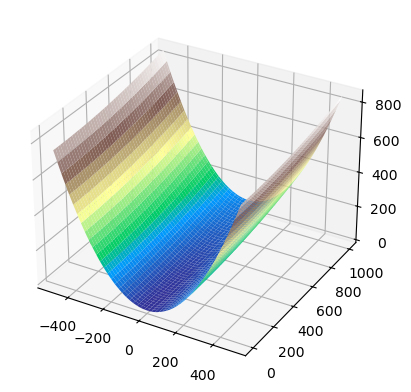

In [5]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(xv,yv,sim_glac,cmap='terrain')

get it into a raster grid

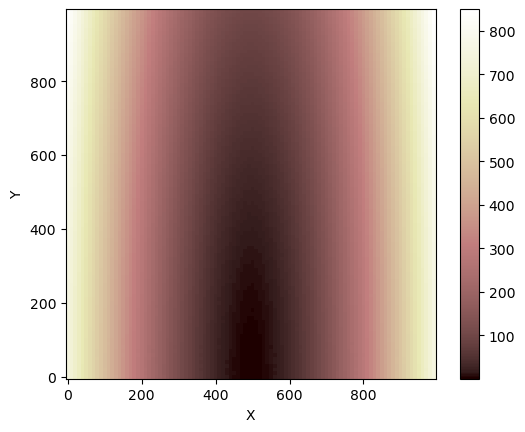

In [6]:
grid = RasterModelGrid(sim_glac.shape, 10.0)
grid.at_node['bedrock__elevation'] = sim_glac
grid.imshow('bedrock__elevation')

In [12]:
# add field 'soil__depth' to the grid
grid.add_ones("soil__depth", at="node", clobber=True)

# Add field 'bedrock__elevation' to the grid
grid.add_zeros("topographic__elevation", at="node", clobber=True)

# Sum 'soil__depth' and 'bedrock__elevation'
# to yield 'topographic elevation'
grid.at_node["bedrock__elevation"][:] = grid.at_node["topographic__elevation"]
grid.at_node["topographic__elevation"][:] += grid.at_node["soil__depth"]

In [13]:
grid.set_closed_boundaries_at_grid_edges(
    bottom_is_closed=False,
    left_is_closed=True,
    right_is_closed=True,
    top_is_closed=True,
)

In [ ]:
# Instantiate flow router
fr = PriorityFloodFlowRouter(mg, flow_metric="D8", suppress_out=True)

# Instantiate SPACE model with chosen parameters
sp = SpaceLargeScaleEroder(
    mg,
    K_sed=2.5e-5,
    K_br=2.5e-5,
    F_f=0.0,
    phi=0.0,
    H_star=1.0,
    v_s=1,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)